# Importing the Liberary 

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier                          # ← added
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,           # ← added
                             recall_score, f1_score, roc_auc_score,     # ← added
                             confusion_matrix, classification_report)
from xgboost import XGBClassifier                                       # ← added

# Importing the Dataset 

In [2]:
data =pd.read_csv("churn_data.csv")
print(data.shape)

(6812, 16)


In [3]:
df=data.copy() # creating a copy of the original data to work with
df.head() # displaying the first few rows of the dataset   

,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,TransactionDate,Year,Month,AmountSpent,ProductCategory,InteractionType,ResolutionStatus,DaysSinceLastInteraction,ChurnStatus
0,62,M,Single,Low,2023-10-21,34,Mobile App,2022-03-27,2022,3,416.50,Electronics,Inquiry,Resolved,274,0
1,65,M,Married,Low,2023-12-05,5,Website,2022-08-08,2022,8,54.96,Clothing,Inquiry,Resolved,288,1
2,65,M,Married,Low,2023-12-05,5,Website,2022-07-25,2022,7,197.50,Electronics,Inquiry,Resolved,288,1
3,65,M,Married,Low,2023-12-05,5,Website,2022-01-25,2022,1,101.31,Furniture,Inquiry,Resolved,288,1
4,65,M,Married,Low,2023-12-05,5,Website,2022-07-24,2022,7,397.37,Clothing,Inquiry,Resolved,288,1


In [4]:
print(df.info()) # checking the data types and missing values in the dataset    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       6812 non-null   int64  
 1   Gender                    6812 non-null   object 
 2   MaritalStatus             6812 non-null   object 
 3   IncomeLevel               6812 non-null   object 
 4   LastLoginDate             6812 non-null   object 
 5   LoginFrequency            6812 non-null   int64  
 6   ServiceUsage              6812 non-null   object 
 7   TransactionDate           6812 non-null   object 
 8   Year                      6812 non-null   int64  
 9   Month                     6812 non-null   int64  
 10  AmountSpent               6812 non-null   float64
 11  ProductCategory           6812 non-null   object 
 12  InteractionType           6812 non-null   object 
 13  ResolutionStatus          6812 non-null   object 
 14  DaysSinc

In [5]:
df['LastLoginDate'] = pd.to_datetime(df['LastLoginDate'])
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

In [6]:
# Verify
print(df[['LastLoginDate', 'TransactionDate']].dtypes)

LastLoginDate      datetime64[ns]
TransactionDate    datetime64[ns]
dtype: object


In [7]:
print(df.isnull().sum()) # checking for missing values in the dataset

Age                         0
Gender                      0
MaritalStatus               0
IncomeLevel                 0
LastLoginDate               0
LoginFrequency              0
ServiceUsage                0
TransactionDate             0
Year                        0
Month                       0
AmountSpent                 0
ProductCategory             0
InteractionType             0
ResolutionStatus            0
DaysSinceLastInteraction    0
ChurnStatus                 0
dtype: int64


In [8]:
df.columns

Index(['Age', 'Gender', 'MaritalStatus', 'IncomeLevel', 'LastLoginDate',
       'LoginFrequency', 'ServiceUsage', 'TransactionDate', 'Year', 'Month',
       'AmountSpent', 'ProductCategory', 'InteractionType', 'ResolutionStatus',
       'DaysSinceLastInteraction', 'ChurnStatus'],
      dtype='object')

In [9]:
# ── 1. Drop date columns (not directly usable as features) ──────────────────
df = df.drop(columns=['LastLoginDate', 'TransactionDate'])

# Feature and Target

In [10]:
# ── 2. Define Features and Target ────────────────────────────────────────────
X = df.drop(columns=['ChurnStatus'])
y = df['ChurnStatus']

# Spliting the data into Train and Test

In [11]:
# ── 3. Split FIRST ────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print('Training set shape:', X_train.shape, y_train.shape)
print('Test set shape:', X_test.shape, y_test.shape)
print('\nChurn distribution in training set:')
print(y_train.value_counts(normalize=True))
print('\nChurn distribution in test set:')
print(y_test.value_counts(normalize=True))

Training set shape: (5449, 13) (5449,)
Test set shape: (1363, 13) (1363,)

Churn distribution in training set:
ChurnStatus
0    0.801615
1    0.198385
Name: proportion, dtype: float64

Churn distribution in test set:
ChurnStatus
0    0.801174
1    0.198826
Name: proportion, dtype: float64


# Encoding the Data 

In [13]:
# Feature categorization based on data types and domain knowledge

ordinal_features  = ['IncomeLevel']
onehot_features   = ['Gender', 'MaritalStatus', 'ServiceUsage',
                     'ProductCategory', 'InteractionType', 'ResolutionStatus']
numeric_features  = ['Age', 'AmountSpent', 'DaysSinceLastInteraction', 'LoginFrequency']

In [14]:
# ── 5. Define Ordinal Category Order ─────────────────────────────────────────
income_order = [['Low', 'Medium', 'High']]

# Building Preprocessor 

In [15]:
preprocessor = ColumnTransformer(transformers=[
    ('num',     StandardScaler(),                              numeric_features),
    ('ordinal', OrdinalEncoder(categories=income_order),       ordinal_features),
    ('onehot',  OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False),            onehot_features),
])

# Define Multiple Models 

In [18]:
models = {
    'Logistic Regression'   : LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'         : DecisionTreeClassifier(random_state=42),
    'Random Forest'         : RandomForestClassifier(random_state=42),
    'Gradient Boosting'     : GradientBoostingClassifier(random_state=42),
    'XGBoost'               : XGBClassifier(random_state=42, eval_metric='logloss'),
    'KNN'                   : KNeighborsClassifier(),
    'SVM'                   : SVC(probability=True, random_state=42),
}

# Train and Evaluate all Models 

In [22]:
results = []

for name, model in models.items():
    
    # Build pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model',        model)
    ])
    
    # Fit
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred      = pipeline.predict(X_test)
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob),
    })
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))


  Logistic Regression
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1092
           1       0.00      0.00      0.00       271

    accuracy                           0.80      1363
   macro avg       0.40      0.50      0.44      1363
weighted avg       0.64      0.80      0.71      1363


  Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1092
           1       0.93      0.92      0.92       271

    accuracy                           0.97      1363
   macro avg       0.95      0.95      0.95      1363
weighted avg       0.97      0.97      0.97      1363


  Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1092
           1       1.00      0.86      0.92       271

    accuracy                           0.97      1363
   macro avg       0.98      0.93      0.95      1363
weighted avg     

# Comparing the Result

In [36]:
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df.index += 1

In [37]:
print("\n📊 Model Comparison:")
print(results_df.to_string())
 


📊 Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1              XGBoost  0.985326   0.992157  0.933579  0.961977  0.991768
2        Random Forest  0.972120   0.995745  0.863469  0.924901  0.991993
3        Decision Tree  0.969919   0.929104  0.918819  0.923933  0.950710
4                  KNN  0.912693   0.855140  0.675277  0.754639  0.938560
5    Gradient Boosting  0.841526   0.923077  0.221402  0.357143  0.851361
6                  SVM  0.818048   0.870968  0.099631  0.178808  0.848952
7  Logistic Regression  0.800440   0.000000  0.000000  0.000000  0.590075


# Selecting Best Model

In [38]:
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

In [39]:
print(f"✅ Best Model Selected: {best_model_name}")

✅ Best Model Selected: XGBoost


# Build Final Pipeline with Best Model

In [40]:
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        best_model)
])

In [41]:
best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'AmountSpent',
                                                   'DaysSinceLastInteraction',
                                                   'LoginFrequency']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High']]),
                                                  ['IncomeLevel']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender', 'MaritalStatus',
                                                   'ServiceUsage',
                                                   'Pro...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

# Predection 

In [42]:
y_pred      = best_pipeline.predict(X_test)
y_pred_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Evaluation Metrics

In [43]:
print(f"\n📊 Final Evaluation — {best_model_name}")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"   Precision : {precision_score(y_test, y_pred):.4f}")
print(f"   Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"   F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")


📊 Final Evaluation — XGBoost
   Accuracy  : 0.9853
   Precision : 0.9922
   Recall    : 0.9336
   F1 Score  : 0.9620
   ROC-AUC   : 0.9918

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1092
           1       0.99      0.93      0.96       271

    accuracy                           0.99      1363
   macro avg       0.99      0.97      0.98      1363
weighted avg       0.99      0.99      0.99      1363



# Over fitting Vs Under fitting

Metric                    Train       Test
Accuracy                 0.9994     0.9853
F1 Score                 0.9986     0.9620
Recall                   0.9972     0.9336

📊 Diagnosis:
   ✅  GOOD FIT     — Train(0.9994) ≈ Test(0.9853)
       Gap: 0.0141
       → Model is generalizing well!


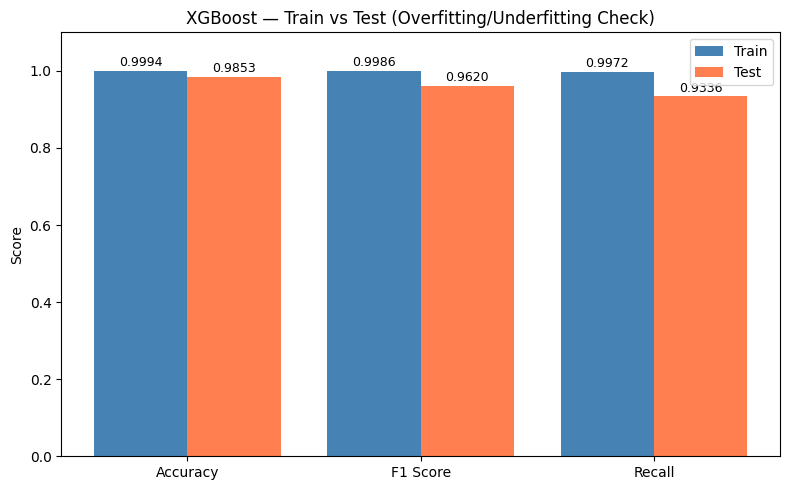

In [44]:
# ── 1. Train & Test Scores ────────────────────────────────────────────────────
train_pred = best_pipeline.predict(X_train)
test_pred  = best_pipeline.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy  = accuracy_score(y_test,  test_pred)

train_f1 = f1_score(y_train, train_pred)
test_f1  = f1_score(y_test,  test_pred)

train_recall = recall_score(y_train, train_pred)
test_recall  = recall_score(y_test,  test_pred)

print("=" * 45)
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("=" * 45)
print(f"{'Accuracy':<20} {train_accuracy:>10.4f} {test_accuracy:>10.4f}")
print(f"{'F1 Score':<20} {train_f1:>10.4f} {test_f1:>10.4f}")
print(f"{'Recall':<20} {train_recall:>10.4f} {test_recall:>10.4f}")
print("=" * 45)

# ── 2. Diagnosis ──────────────────────────────────────────────────────────────
gap = train_accuracy - test_accuracy

print("\n📊 Diagnosis:")
if train_accuracy < 0.80 and test_accuracy < 0.80:
    print("   ⚠️  UNDERFITTING — Both Train & Test accuracy are low")
    print("       → Try more complex model or add more features")
elif gap > 0.05:
    print(f"   ⚠️  OVERFITTING  — Train({train_accuracy:.4f}) >> Test({test_accuracy:.4f})")
    print(f"       Gap: {gap:.4f}")
    print("       → Try regularization, reduce complexity or more data")
else:
    print(f"   ✅  GOOD FIT     — Train({train_accuracy:.4f}) ≈ Test({test_accuracy:.4f})")
    print(f"       Gap: {gap:.4f}")
    print("       → Model is generalizing well!")

# ── 3. Visual Comparison ──────────────────────────────────────────────────────
metrics      = ['Accuracy', 'F1 Score', 'Recall']
train_scores = [train_accuracy, train_f1, train_recall]
test_scores  = [test_accuracy,  test_f1,  test_recall]

x = range(len(metrics))

plt.figure(figsize=(8, 5))
bars1 = plt.bar([i - 0.2 for i in x], train_scores, width=0.4,
                label='Train', color='steelblue')
bars2 = plt.bar([i + 0.2 for i in x], test_scores,  width=0.4,
                label='Test',  color='coral')

# Add value labels on bars
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('XGBoost — Train vs Test (Overfitting/Underfitting Check)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Cross-validation on training data ─────────────────────────────────────────
cv = 5
cv_accuracy = cross_val_score(best_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(best_pipeline, X_train, y_train, cv=cv, scoring='f1')
cv_recall = cross_val_score(best_pipeline, X_train, y_train, cv=cv, scoring='recall')

print(f"Cross-validation ({cv}-fold) results on training data:")
print(f"   Accuracy : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"   F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"   Recall   : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")

# Feature Importance 

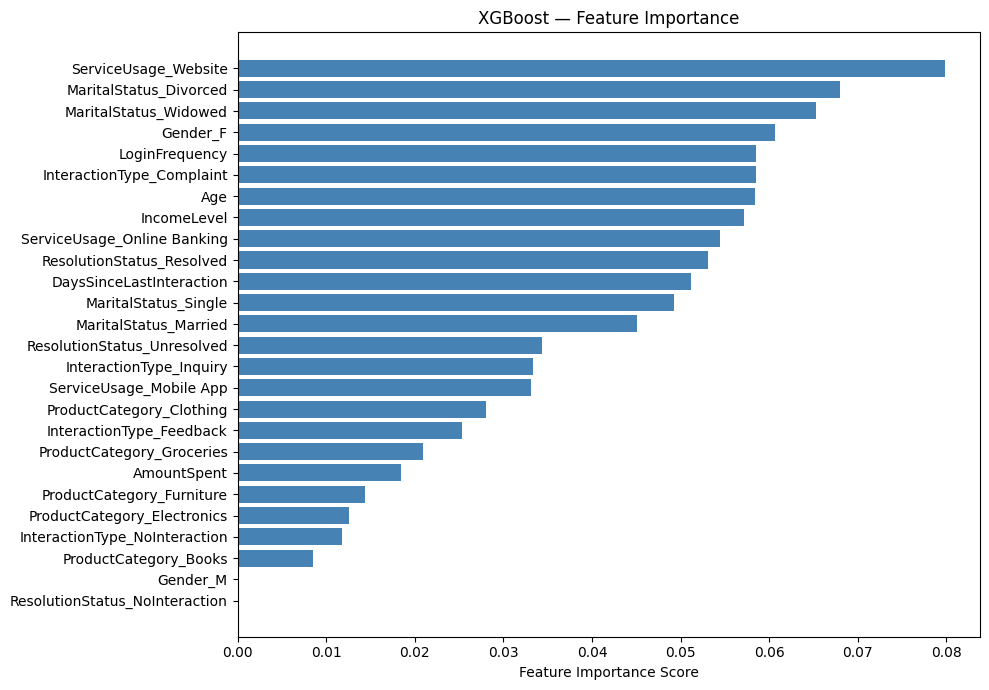


📊 Top 10 Most Important Features:
   1. ServiceUsage_Website                0.0798
   2. MaritalStatus_Divorced              0.0680
   3. MaritalStatus_Widowed               0.0652
   4. Gender_F                            0.0606
   5. LoginFrequency                      0.0585
   6. InteractionType_Complaint           0.0585
   7. Age                                 0.0584
   8. IncomeLevel                         0.0571
   9. ServiceUsage_Online Banking         0.0545
   10. ResolutionStatus_Resolved           0.0531


In [46]:
import matplotlib.pyplot as plt
import numpy as np

# ── Feature Importance ────────────────────────────────────────────────────────
# Get the XGBoost model from the pipeline
xgb_model = best_pipeline.named_steps['model']

# Get feature names after preprocessing
num_feature_names = numeric_features
ordinal_feature_names = ordinal_features
onehot_feature_names = best_pipeline.named_steps['preprocessor']\
    .named_transformers_['onehot'].get_feature_names_out(onehot_features).tolist()

all_feature_names = num_feature_names + ordinal_feature_names + onehot_feature_names

# Get feature importances
importances = xgb_model.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]
sorted_features = [all_feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 7))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.show()

# Print top features
print("\n📊 Top 10 Most Important Features:")
for i in range(min(10, len(sorted_features))):
    print(f"   {i+1}. {sorted_features[i]:<35} {sorted_importances[i]:.4f}")

# Confusion Matrix

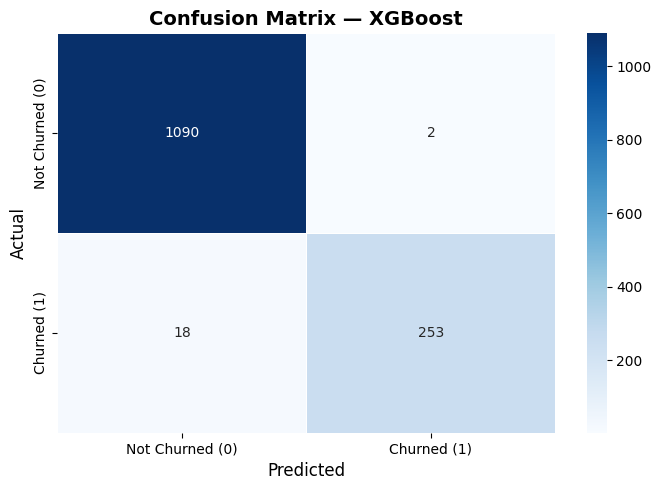

True  Negative  (TN) : 1090  → Correctly predicted NOT Churned
False Positive  (FP) : 2  → Predicted Churned but actually NOT
False Negative  (FN) : 18  → Missed actual Churners ⚠️
True  Positive  (TP) : 253  → Correctly predicted Churned ✅

Total Test Samples   : 1363


In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── 1. Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

# ── 2. Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Not Churned (0)', 'Churned (1)'],
            yticklabels=['Not Churned (0)', 'Churned (1)'],
            linewidths=0.5)

plt.title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# ── 3. Print Values ───────────────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()

print(f"True  Negative  (TN) : {tn}  → Correctly predicted NOT Churned")
print(f"False Positive  (FP) : {fp}  → Predicted Churned but actually NOT")
print(f"False Negative  (FN) : {fn}  → Missed actual Churners ⚠️")
print(f"True  Positive  (TP) : {tp}  → Correctly predicted Churned ✅")
print(f"\nTotal Test Samples   : {tn+fp+fn+tp}")

# ROC Curve 

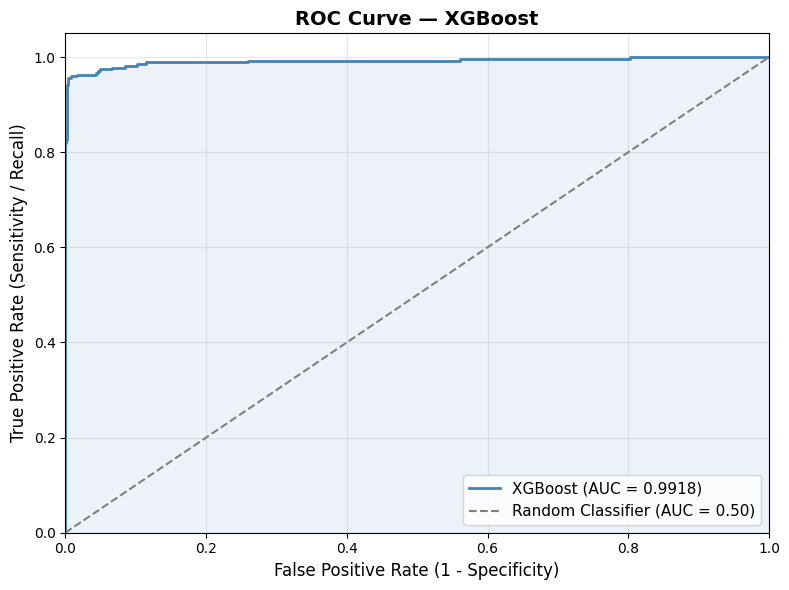

ROC-AUC Score: 0.9918


In [50]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
# ── 1. Get ROC Curve Data ─────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# ── 2. Plot ROC Curve ─────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'XGBoost (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5,
         linestyle='--', label='Random Classifier (AUC = 0.50)')

plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title(f'ROC Curve — {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

# Adding Pickle File 

In [52]:
import joblib

# Save the already trained model
joblib.dump(best_pipeline, 'churn_model.pkl')
print("✅ Model saved as churn_model.pkl")

✅ Model saved as churn_model.pkl
